# VQ-Variational Autoencoders

- Implement on same MNIST example
- Unconditional and conditional examples


In [2]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#PyTorch Libraries
import torch
import torch.nn as nn
import torchvision

import torchvision.transforms.v2 as transforms

from torch.utils.data import Dataset, DataLoader


In [3]:
## We will use a GPU if possible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cpu')

In [4]:
## We'll get the MNIST dataset from torchvision.datasets

from torchvision.datasets import MNIST

#Also, we'll want to transform ToTensor:
from torchvision.transforms import ToTensor

#Get the train and test sets:
#######

mnist_trainset = MNIST(root='./', train=True, download=True, transform=ToTensor())

mnist_testset = MNIST(root='./', train=False, download=True, transform=ToTensor())

In [5]:
## Let's use Subset from torch.utils.data to get a validation set:
########

from torch.utils.data import Subset

indices1 = range(0, int(55e3), 1)
indices2 = range(int(55e3), int(60e3), 1)

mnist_train = Subset(mnist_trainset, indices1)
mnist_valid = Subset(mnist_trainset, indices2)


In [6]:
#Put into a DataLoader:

train_loader = DataLoader(mnist_train, batch_size=32, shuffle=True)
valid_loader = DataLoader(mnist_valid, batch_size=32, shuffle=False)

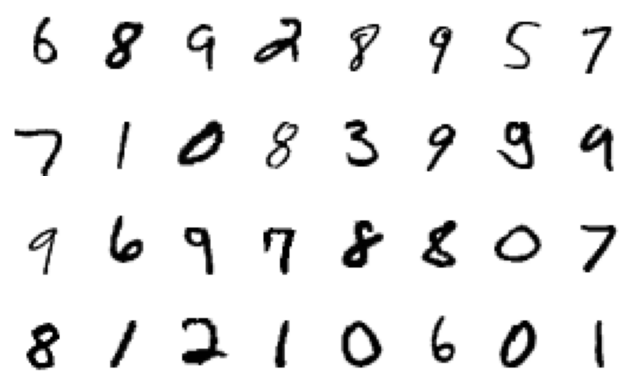

In [7]:
#Plot some examples:
######

fig1, ax1 = plt.subplots(4, 8, figsize=(8,5))

#Flatten for easier indexing
ax1 = ax1.flatten()

X, y = next(iter(train_loader))

#And plot:
for i in range(32):

    im = ax1[i].imshow(X[i].numpy().squeeze(), cmap='gray_r')
    ax1[i].set_axis_off()


In [8]:
## VQ-VAE
############

# We encode, and then match to the closest vector in a codebook
# Jointly train the codebook vectors with the encoder/decoder:

# Better do, then can do stable diffusion in latent space with VQ-VAE

# Idea: We have a standard encoder, will give us a 1xD vector as the latent coding
# Then, have a nn.Embedding layer of size KxD that gives us the codebook vectors
# Find closest, map to this, and use straightthrough trick to keep gradients
# Save codebook and commitment losses
# Total loss is MSE + codebook + commitment losses

In [9]:
## First define the Encoder separately:
###

class VQ_VAE_Encoder(nn.Module):

    def __init__(self, input_dim, z_dim):
        super().__init__()

        self.linear1 = nn.Linear(input_dim, 128)
        self.linear2 = nn.Linear(128, 64)
        self.linear3 = nn.Linear(64, z_dim)

        self.relu = nn.ReLU()

    def forward(self, x):

        #Run the encoder, get standard z_dim vector
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.linear3(x)

        return x


In [10]:
class VQ_VAE_Decoder(nn.Module):

    def __init__(self, z_dim, output_dim):
        super().__init__()

        self.linear1 = nn.Linear(z_dim, 64)
        self.linear2 = nn.Linear(64, 128)
        self.linear3 = nn.Linear(128, output_dim)

        self.relu = nn.ReLU()

    def forward(self, z):

        #Run the decoder given z, which will come from the codebook, ultimately
        z = self.relu(self.linear1(z))
        z = self.relu(self.linear2(z))
        z = self.linear3(z)

        return z


In [11]:
#Check finding closest element in a codebook:
######

K=128
D=16

codebook = nn.Embedding(K, D)
codebook(torch.tensor(0))

tensor([-0.2577,  0.4284,  0.3786,  0.7670,  1.2546, -1.6506,  1.0381,  1.3004,
         0.9782,  0.8579,  1.1843,  0.4937, -0.8284, -0.2206,  0.2452,  0.3948],
       grad_fn=<EmbeddingBackward0>)

In [12]:
#Some random vectors
z = torch.randn((32,D))
z

#Matrix of distances
distances = torch.cdist(z, codebook.weight, p=2)

#Closest index for each
closest_index = torch.argmin(distances, axis=-1)
closest_index.shape

torch.Size([32])

In [13]:
#Check that it seems right:
####

print(torch.cdist(z[[0],:], codebook.weight[[closest_index[0]],:]))

print(closest_index[0])

print(torch.cdist(z[[0],:], codebook.weight))

tensor([[3.6850]], grad_fn=<CdistBackward0>)
tensor(81)
tensor([[5.0716, 6.1793, 7.8858, 7.1306, 7.3431, 6.8325, 7.8103, 6.8193, 6.1646,
         7.1305, 7.4946, 5.8714, 5.5261, 4.8813, 6.6768, 6.2561, 6.9304, 6.0732,
         7.1904, 5.7369, 6.0491, 5.1136, 6.8034, 7.4465, 6.8145, 6.2486, 5.0449,
         6.5449, 7.5617, 6.2154, 5.7664, 6.3187, 7.3501, 6.3702, 4.7052, 5.3315,
         7.5419, 4.8781, 5.9939, 5.9153, 7.4979, 6.0779, 7.2583, 6.8914, 7.1148,
         5.9251, 5.8585, 6.2306, 5.6804, 7.4070, 6.8159, 6.8140, 5.9360, 5.9869,
         5.6230, 5.6132, 5.2775, 6.4697, 6.6520, 6.8333, 6.8122, 6.5399, 6.5603,
         4.9008, 5.6138, 3.8803, 5.9469, 7.2365, 7.2877, 6.4621, 6.7496, 6.3694,
         7.0306, 7.2242, 6.5513, 6.4816, 4.1563, 4.9537, 6.7022, 6.2668, 5.3719,
         3.6850, 6.1018, 5.1662, 5.6570, 6.7278, 6.1947, 5.3819, 6.7791, 6.5964,
         5.1370, 7.1246, 6.3433, 5.6753, 6.3381, 5.7625, 6.6693, 6.1502, 6.4000,
         7.0377, 5.9396, 7.4854, 5.3018, 6.5844, 6.07

In [14]:
class VQVAE(nn.Module):

    def __init__(self, input_dim, K, D):

        super().__init__()

        #Create the encoder
        self.encoder = VQ_VAE_Encoder(input_dim, D)
        self.decoder = VQ_VAE_Decoder(D, input_dim)

        self.codebook = nn.Embedding(K, D)
        self.codebook.weight.data.uniform_(-1/np.sqrt(D), 1/np.sqrt(D))
        
    #Given z_e, our initial latent encoding, find the closest vector in the codebook
    def get_codebook_vector(self, z_e):

        distances = torch.cdist(z_e, self.codebook.weight, p=2)
        closest_indices = torch.argmin(distances, axis=-1)

        #Get the new z_q:
        z_q = self.codebook(closest_indices)
        
        #And do the straightthrough trick:
        z_q = z_e + (z_q - z_e).detach()
        
        return z_q


    #Run the model in training mode:
    def forward(self, x):

        #First encode:
        z_e = self.encoder(x)

        #Essential to normalize or get huge drift
        z_e = torch.nn.functional.normalize(z_e, dim=-1)
        
        #get_codebook_vector:
        z_q = self.get_codebook_vector(z_e)

        
        #print(z_e)
        #print(z_q)
        #Finally decode:
        x_out = self.decoder(z_q)

        #Return the x_out, z_e, and z_q: Need the latter for codebook and commitment loss
        return x_out, z_e, z_q


In [15]:
## Set up VQ-VAE:
########

K=1024
D=16
vq_vae = VQVAE(input_dim=1*28*28, D=D, K=K)

vq_vae = vq_vae.to(device)

In [16]:
#Reconstruction loss Function:
mse_loss = nn.MSELoss()

#And Optimizer:
optimizer = torch.optim.Adam(vq_vae.parameters(), lr=0.001)

In [17]:
## Confirm we can run:
##

X_in, y = next(iter(train_loader))


X_in = X_in.to(device)
y = y.to(device)

X_in = X_in.flatten(1)


#Will train on our input:
X_out, z_e, z_q = vq_vae(X_in)


In [ ]:
## Run the training loop for a number of epochs
loss_list = []

vq_vae.train()

num_epochs=5
for epoch in range(num_epochs):

    for batch in train_loader:
        #Unpack to X and y
        X_in, y = batch

        X_in = X_in.to(device)
        y = y.to(device)

        X_in = X_in.flatten(1)

        
        #Train on our input:
        X_out, z_e, z_q = vq_vae(X_in)

        
        #Losses:
        
        codebook_loss = torch.mean(mse_loss(z_e.detach(), z_q))
        commitment_loss = torch.mean(mse_loss(z_e, z_q.detach()))
        recon_loss = mse_loss(X_out, X_in)
        
        #print(recon_loss)
        #print(codebook_loss)
        #print(commitment_loss)
        
        loss = recon_loss + codebook_loss + .25*commitment_loss

        #Backprop
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.item())

    #print(epoch)
    #print(loss.item())

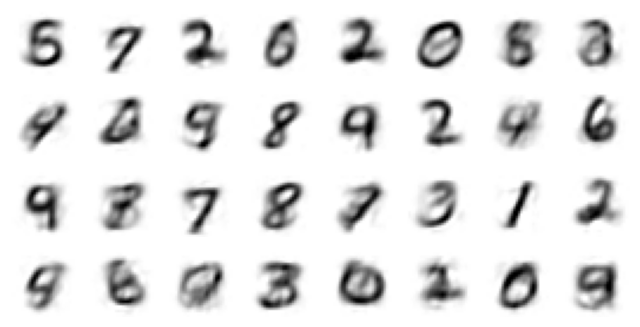

In [22]:
#### Plot some outputs of autoencoder:
#########
fig1, ax1 = plt.subplots(4, 8, figsize=(8,4))

#ax1=ax1.flatten()

#And plot:
for y_val in range(4):
    for i in range(8):

        #And reconstruction:
        vq_vae.eval()

        with torch.no_grad():
            
            z = vq_vae.codebook(torch.randint(0,1024,(1,)).to(device))

            image = vq_vae.decoder(z.to(device)).view(1,28,28).cpu()

        #Can clip to 0, 1:
        image = np.clip(image, 0, 1)

        ax1[y_val, i].imshow(image.permute(1,2,0), cmap='gray_r')
        ax1[y_val, i].set_axis_off()

### Re-do as class-conditional:

In [23]:
## First define the Encoder separately:
###

class Cond_VQ_VAE_Encoder(nn.Module):

    #Only change is we added num_classes inputs - will be one-hotted
    def __init__(self, input_dim, num_classes, z_dim):
        super().__init__()

        self.linear1 = nn.Linear(input_dim+num_classes, 128)
        self.linear2 = nn.Linear(128, 64)
        self.linear3 = nn.Linear(64, z_dim)

        self.relu = nn.ReLU()

    #Expect one-hot classes as last num_classes entries in x
    def forward(self, x):

        #Run the encoder, get standard z_dim vector
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.linear3(x)

        return x


In [24]:
class Cond_VQ_VAE_Decoder(nn.Module):

    #Again, add num_classes for input:
    def __init__(self, z_dim, num_classes, output_dim):
        super().__init__()

        self.linear1 = nn.Linear(z_dim + num_classes, 64)
        self.linear2 = nn.Linear(64, 128)
        self.linear3 = nn.Linear(128, output_dim)

        self.relu = nn.ReLU()

    def forward(self, z):

        #Run the decoder given z, which will come from the codebook, ultimately
        z = self.relu(self.linear1(z))
        z = self.relu(self.linear2(z))
        z = self.linear3(z)

        return z


In [25]:
class Cond_VQVAE(nn.Module):

    def __init__(self, input_dim, num_classes, K, D):

        super().__init__()

        #Save num_classes
        self.num_classes = num_classes
        
        #Create the encoder and decoder
        self.encoder = Cond_VQ_VAE_Encoder(input_dim, num_classes, D)
        self.decoder = Cond_VQ_VAE_Decoder(D, num_classes, input_dim)

        self.codebook = nn.Embedding(K, D)
        self.codebook.weight.data.uniform_(-1/np.sqrt(D), 1/np.sqrt(D))
        
    #Given z_e, our initial latent encoding, find the closest vector in the codebook
    def get_codebook_vector(self, z_e):

        distances = torch.cdist(z_e, self.codebook.weight, p=2)
        closest_indices = torch.argmin(distances, axis=-1)

        #Get the new z_q:
        z_q = self.codebook(closest_indices)
        
        #And do the straightthrough trick:
        z_q = z_e + (z_q - z_e).detach()
        
        return z_q


    #Run the model in training mode:
    def forward(self, x):

        #First encode:
        z_e = self.encoder(x)

        #Essential to normalize or get huge drift
        z_e = torch.nn.functional.normalize(z_e, dim=-1)
        
        #get_codebook_vector:
        z_q = self.get_codebook_vector(z_e)

        #Main change:
        #Add class one-hot vector
        z = torch.cat((z_q, x[:,-self.num_classes:]), dim=-1)
        
        #Finally decode:
        x_out = self.decoder(z)

        return x_out, z_e, z_q


In [26]:
## Convolutional conditional VAE
########

K=1024
D=16
cond_vq_vae = Cond_VQVAE(input_dim=1*28*28, num_classes=10, D=D, K=K)

cond_vq_vae = cond_vq_vae.to(device)

In [27]:
#Reconstruction loss Function:
mse_loss = nn.MSELoss()

#And Optimizer:
optimizer = torch.optim.Adam(cond_vq_vae.parameters(), lr=0.001)

In [ ]:
## Run the training loop
loss_list = []

cond_vq_vae.train()

num_epochs=5
for epoch in range(num_epochs):

    for batch in train_loader:
        #Unpack to X and y
        X_in, y = batch

        X_in = X_in.flatten(1)
        
        ## Augment input to include classes:
        y_one_hot = torch.nn.functional.one_hot(y, 10) #Add one-hot classes to input
        X_in_aug = torch.cat((X_in, y_one_hot), axis=-1)
        
        
        X_in = X_in.to(device)
        X_in_aug = X_in_aug.to(device)
        y = y.to(device)

        

        #Train on our input:
        X_out, z_e, z_q = cond_vq_vae(X_in_aug)

        
        #Loss:
        
        codebook_loss = torch.mean(mse_loss(z_e.detach(), z_q))
        commitment_loss = torch.mean(mse_loss(z_e, z_q.detach()))
        recon_loss = mse_loss(X_out, X_in)
        
        #print(recon_loss)
        #print(codebook_loss)
        #print(commitment_loss)
        
        loss = recon_loss + codebook_loss + .25*commitment_loss

        #Backprop
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.item())

    #print(epoch)
    #print(loss.item())

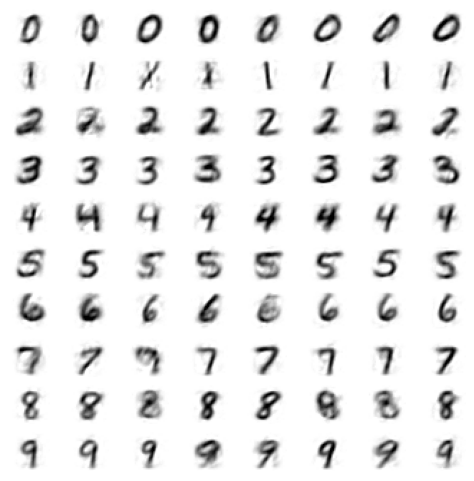

In [29]:
#### Plot outputs of autoencoder:
#########
fig1, ax1 = plt.subplots(10, 8, figsize=(6,6))

#ax1=ax1.flatten()

#And plot:
for y_val in range(10):
    for i in range(8):

        vq_vae.eval()

        with torch.no_grad():
            
            z = cond_vq_vae.codebook(torch.randint(0,1024,(1,))).to(device)
            y_one_hot = torch.nn.functional.one_hot(torch.tensor(y_val), 10).unsqueeze(0).to(device)
            
            z = torch.cat((z, y_one_hot), axis=-1)
            
            image = cond_vq_vae.decoder(z.to(device)).view(1,28,28).cpu()

        #Can clip to 0, 1:
        image = np.clip(image, 0, 1)

        ax1[y_val, i].imshow(image.permute(1,2,0), cmap='gray_r')
        ax1[y_val, i].set_axis_off()
        
    